In [52]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [53]:
class Die:
    def __init__(self):
        self.sides = 6

    def roll(self):
        return random.randint(1, self.sides)
    
    def __del__(self):
        pass

In [54]:
class DiceBatch:
    def __init__(self):
        self.dice = [Die() for _ in range(3)]

    def roll_all(self):
        rolls = [die.roll() for die in self.dice]
        return rolls

In [55]:
class DiceGame:
    def __init__(self):
        self.player1 = DiceBatch()
        self.player2 = DiceBatch()
        self.score1 = 0
        self.score2 = 0
        self.history = []

    def play_round(self):
        rolls1 = self.player1.roll_all()
        rolls2 = self.player2.roll_all()

        sum1 = sum(rolls1)
        sum2 = sum(rolls2)

        triple1_p1 = rolls1 == [1, 1, 1]
        triple1_p2 = rolls2 == [1, 1, 1]

        round_score1 = 0
        round_score2 = 0

        if triple1_p1:
            round_score1 += 1
        if triple1_p2:
            round_score2 += 1

        if not triple1_p1 and not triple1_p2:
            if sum1 > sum2:
                round_score1 = 1
            elif sum2 > sum1:
                round_score2 = 1
            else:
                round_score1 = 0.5
                round_score2 = 0.5

        self.score1 += round_score1
        self.score2 += round_score2

        self.history.append({
            "p1_rolls": rolls1,
            "p2_rolls": rolls2,
            "p1_sum": sum1,
            "p2_sum": sum2,
            "score1": self.score1,
            "score2": self.score2
        })

    def play_game(self):
        while True:
            self.play_round()

            if self.score1 >= 5 or self.score2 >= 5:
                if self.score1 != self.score2:
                    break

        return 1 if self.score1 > self.score2 else 2

In [69]:
games = 50
player1_wins = 0
all_rolls = []
winner_rolls = []
loser_rolls = []

for _ in range(games):
    game = DiceGame()
    winner = game.play_game()

    if winner == 1:
        player1_wins += 1
    
    for round_data in game.history:
        p1_rolls = round_data["p1_rolls"]
        p2_rolls = round_data["p2_rolls"]

        sum1 = round_data["p1_sum"]
        sum2 = round_data["p2_sum"]

        all_rolls.extend(p1_rolls)
        all_rolls.extend(p2_rolls)

        if sum1 > sum2:
            winner_rolls.extend(p1_rolls)
            loser_rolls.extend(p2_rolls)
        elif sum2 > sum1:
            winner_rolls.extend(p2_rolls)
            loser_rolls.extend(p1_rolls)

In [70]:
probability = player1_wins / games
print("Player 1 wins probs", probability)

Player 1 wins probs 0.54


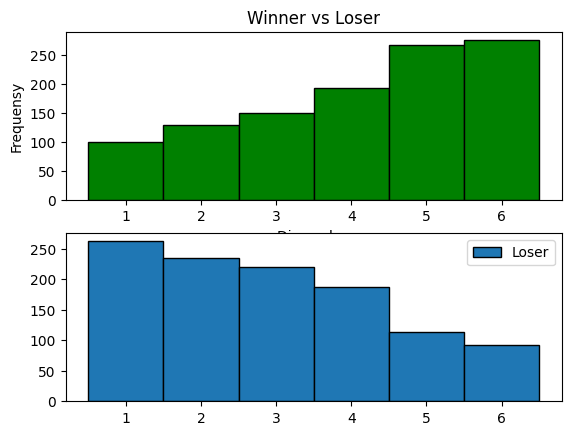

In [ ]:


fig, x = plt.subplots(2)

x[0].hist(winner_rolls, bins=np.arange(1,8)-0.5, label="Winner", color='green', edgecolor='black', stacked=False)
x[1].hist(loser_rolls, bins=np.arange(1,8)-0.5, label="Loser", edgecolor='black')

x[0].set_xlabel("Dice value")
x[0].set_ylabel("Frequensy")
x[0].set_title("Winner vs Loser")
plt.xticks(range(1, 7))
plt.legend()

plt.show()

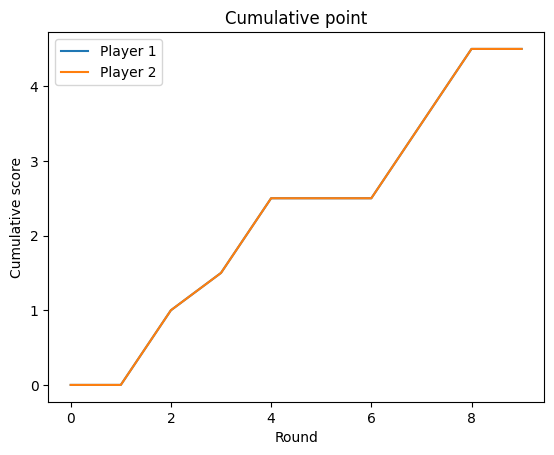

In [59]:
sample_game = DiceGame()
sample_game.play_game()

p1_scores = [r["score1"] for r in sample_game.history]
p2_scores = [r["score2"] for r in sample_game.history]

plt.plot(p1_scores, label="Player 1")
plt.plot(p1_scores, label="Player 2")
plt.xlabel("Round")
plt.ylabel("Cumulative score")
plt.legend()
plt.title("Cumulative point")
plt.show()

In [60]:
observed = [all_rolls.count(i) for i in range(1, 7)]
expected = [len(all_rolls) / 6] * 6
chi1 , p = stats.chisquare(observed, expected)

print("Chi-square p-alue:", p)

Chi-square p-alue: 0.797415627806285


In [61]:
sums = []
for _ in range(500):
    batch = DiceBatch()
    sums.append(sum(batch.roll_all()))
stat, p = stats.shapiro(sums)
print("Shapiro p-value:", p)

Shapiro p-value: 1.6353838586072145e-05
